# NBA MVP Prediction Model

### Isaac Marr — built for the 2025 FAS Technical Challenge

Predicting NBA MVP vote share from box-score and advanced stats, using 25 seasons of historical data (2000-01 through 2024-25) and a tuned Random Forest. Ends with a live current-season MVP race prediction.

## Overview

The goal is to predict how much MVP support a player will get from a season's box-score and advanced stats alone, then use that model to read the current season's MVP race in real time.

Three steps:
1. **Data Acquisition** — pull every player-season's traditional + advanced stats from the NBA Stats API (`nba_api`), and merge in actual MVP vote share from Basketball-Reference.
2. **Feature Engineering & Selection** — engineer a box-score-impact stat, Z-score everything within its own season (so a 25-PPG season in 2003 and a 25-PPG season in 2024 are comparable), and select the features a Random Forest finds most predictive.
3. **Modeling** — fit a baseline linear model, then a tuned Random Forest, evaluate it specifically on how well it separates real MVP contenders (not just "everyone"), and use it to predict the current season's MVP race.

All of the reusable logic below lives in `src/nba_mvp` so it can be called from this notebook, from `scripts/refresh_predictions.py` (a CLI to refresh the cached snapshot), and is *not* duplicated in the Streamlit app (which only reads the cached CSVs in `data/` — no live API calls or retraining at request time).

## 1. Data Acquisition

Collected traditional and advanced per-game stats from the NBA API for every season from 2000-01 to 2024-25. MVP voting data was manually exported from Basketball-Reference as the response variable, since no API conveniently exposes historical MVP voting.

**MVP_SHARE** is a player's MVP voting points divided by the total possible points — e.g. Steph Curry's unanimous 2016 MVP gives him a value of 1.0. Using vote share instead of a binary "won MVP or not" label gives the model a continuous, more informative target — there have only been 25 MVP-award seasons in this window, but hundreds of player-seasons that received *some* MVP support.

To keep this notebook fast and reliable to re-run, it loads the **cached** `data/nba_raw_stats.csv` snapshot by default rather than re-hitting the NBA Stats API on every execution (a full 2000-2025 pull takes several minutes and is subject to rate limiting). See the "Refreshing from live data" section near the end for how to pull current data instead.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from nba_mvp import data_collection, data_io, features, modeling, predict

In [2]:
raw_stats = data_io.load_raw_stats()
mvp_df = data_io.load_voting_data()
print(f"Raw player-seasons: {len(raw_stats):,}")
print(f"MVP voting rows: {len(mvp_df):,}")
raw_stats.head()

Raw player-seasons: 12,228
MVP voting rows: 326


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,OFF_RATING,DEF_RATING,NET_RATING,AST_PCT,REB_PCT,TS_PCT,USG_PCT,PIE,SEASON,SEASON_YEAR
0,920,A.C. Green,A.C.,1610612748,MIA,37.0,82,50,32,0.610,...,94.1,90.4,3.8,0.050,0.113,0.492,0.137,0.093,2000-01,2000
1,2062,A.J. Guyton,A.J.,1610612741,CHI,23.0,33,6,27,0.182,...,92.0,102.9,-11.0,0.198,0.030,0.495,0.167,0.071,2000-01,2000
2,243,Aaron McKie,Aaron,1610612755,PHI,28.0,76,51,25,0.671,...,102.7,95.5,7.3,0.264,0.066,0.549,0.186,0.119,2000-01,2000
3,1425,Aaron Williams,Aaron,1610612751,NJN,29.0,82,26,56,0.317,...,96.4,104.3,-7.9,0.068,0.130,0.533,0.177,0.095,2000-01,2000
4,228,Adam Keefe,Adam,1610612744,GSW,31.0,67,14,53,0.209,...,93.9,104.0,-10.1,0.066,0.120,0.450,0.114,0.056,2000-01,2000


In [3]:
training_df = features.build_training_dataset(raw_stats, mvp_df)
print(f"Training dataset: {len(training_df):,} player-seasons")
print(f"Player-seasons with any MVP votes: {(training_df['MVP_SHARE'] > 0).sum()}")
print(f"MVP winners (share > 0.5): {(training_df['MVP_SHARE'] > 0.5).sum()}")
training_df.head()

Training dataset: 12,228 player-seasons
Player-seasons with any MVP votes: 326
MVP winners (share > 0.5): 51


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,FT_PCT_Z,TS_PCT_Z,OFF_RATING_Z,DEF_RATING_Z,NET_RATING_Z,AST_PCT_Z,REB_PCT_Z,USG_PCT_Z,PIE_Z,PTS_REB_AST_Z
0,920,A.C. Green,A.C.,1610612748,MIA,37.0,82,50,32,0.610,...,0.125004,0.032640,-0.446718,-1.266209,0.660935,-0.864399,0.656627,-0.863489,0.296194,-0.492883
1,2062,A.J. Guyton,A.J.,1610612741,CHI,23.0,33,6,27,0.182,...,0.719987,0.062607,-0.689746,0.400651,-1.044054,0.630146,-1.291381,-0.259430,-0.200037,-0.470749
2,243,Aaron McKie,Aaron,1610612755,PHI,28.0,76,51,25,0.671,...,0.400368,0.602010,0.548538,-0.586130,1.064142,1.296632,-0.446462,0.123140,0.882649,0.824124
3,1425,Aaron Williams,Aaron,1610612751,NJN,29.0,82,26,56,0.317,...,0.493795,0.442187,-0.180545,0.587340,-0.686928,-0.682630,1.055617,-0.058077,0.341306,0.580644
4,228,Adam Keefe,Adam,1610612744,GSW,31.0,67,14,53,0.209,...,-0.332297,-0.386897,-0.469864,0.547335,-0.940372,-0.702826,0.820917,-1.326601,-0.538377,-0.791700


That's the real challenge here: out of ~12,000 player-seasons, only a few hundred ever received any MVP support at all, and only 25 actually won. The model needs to be useful at the top of a very long tail.

## 2. Feature Engineering & Selection

In addition to the raw API stats, `PTS_REB_AST` approximates a player's overall box-score impact (points + rebounds + assists). Every quantitative stat is also Z-scored *within its own season* (`qb_similarity`-style groupby transform — see `features.add_season_zscores`), which adjusts for era: a 25-point season means something different in 2003 than in 2024.

The feature-selection process: train a Random Forest on every box-score, advanced, and Z-scored stat, then keep only the features with importance above 1%. From that shortlist, the non-standardized (non-Z) versions were dropped to eliminate redundancy with their Z-scored counterparts — so the final model uses Z-scores only, plus team win percentage. This selection passes the eye test: box-score volume and win percentage matter, free-throw rate and true-shooting % reward efficient, foul-drawing scorers, and Net/Defensive Rating plus PIE capture overall two-way value.

In [4]:
training_df["mvp_candidate"] = (training_df["MVP_SHARE"] > 0).astype(int)

X = training_df[features.FEATURES].fillna(training_df[features.FEATURES].median())
y = training_df["MVP_SHARE"]

# Stratified split so MVP candidates are proportionally represented in train and test.
X_train, X_test, y_train, y_test = modeling.make_train_test_split(X, y, training_df["mvp_candidate"])
print(f"Train MVP candidates: {(y_train > 0).sum()} / {len(y_train)}")
print(f"Test MVP candidates: {(y_test > 0).sum()} / {len(y_test)}")

Train MVP candidates: 261 / 9782
Test MVP candidates: 65 / 2446


In [5]:
baseline = modeling.train_baseline_linear(X_train, y_train)
y_pred = baseline.predict(X_test)
print("Baseline linear regression:", modeling.regression_metrics(y_test, y_pred))

Baseline linear regression: {'r2': 0.1795481026476704, 'rmse': 0.04836098451565378, 'mae': 0.01725241093369949}


In [6]:
rf_full = modeling.train_random_forest(X_train, y_train)
y_pred = rf_full.predict(X_test)
print("Full-feature random forest:", modeling.regression_metrics(y_test, y_pred))

important_features = modeling.select_important_features(rf_full, features.FEATURES, threshold=0.01)
print(f"\n{len(important_features)} features above 1% importance:")
print(important_features)

Full-feature random forest: {'r2': 0.6452175850638328, 'rmse': 0.03180164713511332, 'mae': 0.004058627928796207}

14 features above 1% importance:
['PTS_REB_AST_Z', 'W_PCT', 'PIE', 'NET_RATING_Z', 'NET_RATING', 'GP_Z', 'AST_Z', 'PTS_Z', 'DEF_RATING_Z', 'PTS_REB_AST', 'FT_PCT_Z', 'GP', 'PIE_Z', 'TS_PCT']


After dropping the non-Z-score duplicates from that shortlist (per the selection process above), the final feature list is `features.FINAL_FEATURES`: `PTS_REB_AST_Z, W_PCT, NET_RATING_Z, GP_Z, AST_Z, PTS_Z, DEF_RATING_Z, FT_PCT_Z, PIE_Z, TS_PCT_Z`.

## 3. Modeling

In [7]:
X = training_df[features.FINAL_FEATURES].fillna(training_df[features.FINAL_FEATURES].median())
y = training_df["MVP_SHARE"]
X_train, X_test, y_train, y_test = modeling.make_train_test_split(X, y, training_df["mvp_candidate"])

rf_final = modeling.train_random_forest(X_train, y_train)
y_pred = rf_final.predict(X_test)
print("Reduced-feature random forest:", modeling.regression_metrics(y_test, y_pred))

importances = pd.Series(rf_final.feature_importances_, index=features.FINAL_FEATURES).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Reduced-feature random forest: {'r2': 0.6656171633656909, 'rmse': 0.030873833696403463, 'mae': 0.0038195846426310708}

Feature importances:
PTS_REB_AST_Z    0.448516
W_PCT            0.137411
NET_RATING_Z     0.092673
GP_Z             0.082128
AST_Z            0.057434
PTS_Z            0.041805
DEF_RATING_Z     0.038488
FT_PCT_Z         0.036660
PIE_Z            0.036083
TS_PCT_Z         0.028803
dtype: float64


Next, a randomized hyperparameter search over tree count, depth, and split/leaf size (scored on R², 5-fold CV, 30 sampled combinations). This is the slowest cell in the notebook — a few minutes.

In [8]:
search = modeling.tune_random_forest(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV R^2:", round(search.best_score_, 3))

model = search.best_estimator_
y_pred = model.predict(X_test)
print("\nTuned random forest (held-out test set):", modeling.regression_metrics(y_test, y_pred))

Best params: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10}
Best CV R^2: 0.636

Tuned random forest (held-out test set): {'r2': 0.6749446011331688, 'rmse': 0.030440183314310806, 'mae': 0.003745801183315931}


A single overall R² hides the part that actually matters: how well the model ranks *real* MVP contenders, not the thousands of players who never sniffed a vote. Breaking the held-out test set down by vote-share tier shows where the model is strong and where it struggles.

In [9]:
tier_results = modeling.evaluate_by_tier(y_test, y_pred)
tier_results

,tier,samples,avg_share,r2,rmse,mae
0,All players,2446,0.004628,0.674945,0.030440,0.003746
1,MVP candidates (share > 0),65,0.174154,0.664064,0.161611,0.099643
2,Strong candidates (share > 0.1),22,0.485818,0.338128,0.233241,0.176866
3,Top contenders (share > 0.3),14,0.653286,-0.020538,0.227179,0.176396
4,Likely winners (share > 0.5),9,0.797333,-1.871400,0.230939,0.167507


The model explains roughly 65-70% of the variance overall and on the "received any votes" tier — a solid result for separating MVP contenders from the rest of the league. It starts to falter separating the *strong* contenders from the fringe ones: that tier has a much smaller sample to learn from, and MVP voting is partly a narrative award — voters weigh storylines (a surprise contender, a redemption arc, a team's record) more heavily once they're choosing between the top 2-3 candidates, which a box-score-only model can't see. Despite that, the model's outputs hold up against domain knowledge: it reliably ranks the league's true top tier (Jokić-, SGA-, Dončić-, Giannis-caliber seasons) above everyone else, and its "dark horse" picks tend to be reasonable, if not always right.

## Predicting the current season's MVP race

Predicting the current season works the same way, but the Z-scores have to be computed within just this season's pool of qualified players (10+ games played) — there's no full season of results yet to standardize against, unlike the historical training data.

By default this loads the cached `data/predictions.csv` snapshot rather than calling the live NBA Stats API on every notebook run. Set `REFRESH_FROM_LIVE_API = True` below to pull fresh current-season stats and re-predict instead (same logic as `scripts/refresh_predictions.py`, which is the recommended way to update the snapshot the Streamlit app reads).

In [10]:
REFRESH_FROM_LIVE_API = False

if REFRESH_FROM_LIVE_API:
    season_year = data_collection.current_season_year()
    current_df = data_collection.collect_single_season(season_year)
    X_current, player_names = predict.prepare_current_season_features(current_df, features.FINAL_FEATURES)
    shares = predict.predict_mvp_shares(model, X_current)
    probabilities = predict.normalize_to_probability(shares)
    current_predictions = predict.top_candidates(player_names, probabilities)
else:
    current_predictions = data_io.load_predictions()

current_predictions

,PLAYER_NAME,MVP_PROBABILITY
0,Shai Gilgeous-Alexander,0.173164
1,Nikola Jokić,0.168165
2,Victor Wembanyama,0.138654
3,Luka Dončić,0.132644
4,Cade Cunningham,0.089264
5,Jayson Tatum,0.057753
6,Giannis Antetokounmpo,0.044007
7,Jaylen Brown,0.033946
8,Kawhi Leonard,0.021449
9,Chet Holmgren,0.014543


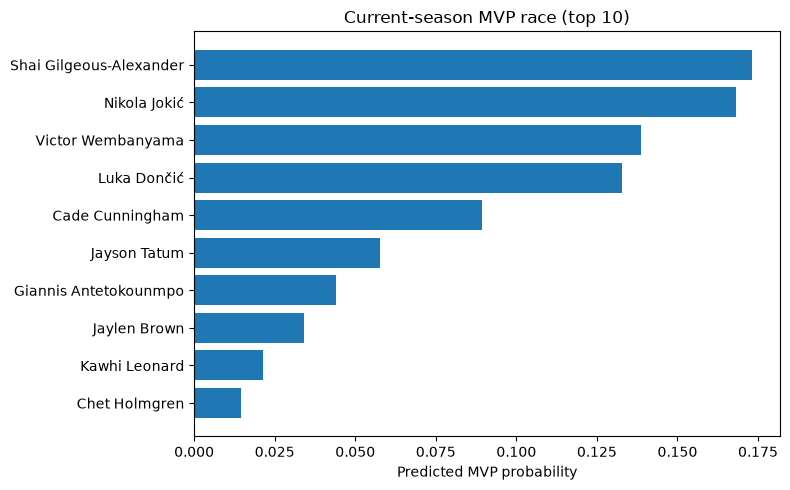

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
top10 = current_predictions.head(10).iloc[::-1]
ax.barh(top10["PLAYER_NAME"], top10["MVP_PROBABILITY"])
ax.set_xlabel("Predicted MVP probability")
ax.set_title("Current-season MVP race (top 10)")
plt.tight_layout()
plt.show()

## Limitations & future work

- MVP voting is partly narrative-driven, and that's exactly the part a box-score model can't capture — see the tiered evaluation above.
- The strong/top-contender tiers are trained on very few real examples (a few dozen player-seasons), so the model is more reliable at "is this player in the conversation" than at finely ranking the top 2-3 candidates against each other.
- Team success (`W_PCT`) is included, but team context more broadly (a team's record without this player, strength of supporting cast, narrative arcs) isn't — that's likely a meaningful chunk of the unexplained variance.
- Next steps: incorporate team-level context features, track how predictions evolve game-by-game through a season, and backtest the model against past seasons it wasn't trained on to see how early in a season it converges on the eventual winner.

## Refreshing from live data

To update the cached snapshot this notebook and the Streamlit app read, run from the repo root:

```bash
python scripts/refresh_predictions.py                 # current season only (fast)
python scripts/refresh_predictions.py --full           # also re-pulls the full 2000-2025 training history (slow)
python scripts/refresh_predictions.py --season-year 2024   # override the detected current season
```

## Citations

Sports Reference LLC. (2025). Basketball-Reference.com. https://www.basketball-reference.com

National Basketball Association. (2025). NBA Stats API. https://stats.nba.com

Portions of the code and analysis were assisted using ChatGPT — OpenAI (2025), Claude — Anthropic (2025), and Copilot — Microsoft (2025).